In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline


In [2]:
from stable_baselines3 import PPO, A2C, DDPG, DQN, SAC
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
import pandas as pd
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.logger import configure

2024-09-08 01:03:20.535828: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-08 01:03:20.543966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-08 01:03:20.554129: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-08 01:03:20.556956: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-08 01:03:20.564537: I tensorflow/core/platform/cpu_feature_guar

In [3]:
def skip_first_fn(params):
    skip_first = max(params['tenkan_period'], params['kijun_period'], params['senkou_span_b_period']) + params['chikou_span_delay']
    return skip_first

def donchian(high,low,len):
    

def calculate_ichimoku(data, params):
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    chikou_span_delay = params['chikou_span_delay']
    
    data['tenkan_ema'] = data.close.ewm(span=tenkan_period, adjust=False).mean()
    data['kijun_ema'] = data.close.ewm(span=kijun_period, adjust=False).mean()
    data['senkou_ema'] = data.close.ewm(span=senkou_span_b_period, adjust=False).mean()

    # Tenkan-sen (Conversion Line)
    data['tenkan_sen'] = (data['close'].rolling(window=tenkan_period).max() + 
                          data['close'].rolling(window=tenkan_period).min()) / 2

    # Kijun-sen (Base Line)
    data['kijun_sen'] = (data['close'].rolling(window=kijun_period).max() + 
                         data['close'].rolling(window=kijun_period).min()) / 2

    # Senkou Span A (Leading Span A)
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(chikou_span_delay)

    # Senkou Span B (Leading Span B)
    data['senkou_span_b'] = ((data['close'].rolling(window=senkou_span_b_period).max() + 
                              data['close'].rolling(window=senkou_span_b_period).min()) / 2).shift(chikou_span_delay)

    # Chikou Span (Lagging Span)
    # data['chikou_span'] = data['close'].shift(-chikou_span_delay)
    
    # data['cloud_upper'] = data[['senkou_span_a', 'senkou_span_b']].max(axis=1)
    # data['cloud_lower'] = data[['senkou_span_a', 'senkou_span_b']].min(axis=1)
    
    # data['close_above_cloud'] = data['close'] > data['cloud_upper']
    # data['close_below_cloud'] = data['close'] < data['cloud_lower']
    
    # data['full_bull'] = (
    #     (data['tenkan_sen'] > data['kijun_sen']) &
    #     (data['close_above_cloud']))
    
    # data['full_bear'] = (
    #     (data['tenkan_sen'] < data['kijun_sen']) &
    #     (data['close_below_cloud']))
    return data
    

IndentationError: expected an indented block after function definition on line 5 (2207793648.py, line 8)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def donchian(data, period):
    """Calculates Donchian channel average."""
    return (data['low'].rolling(window=period).min() + data['high'].rolling(window=period).max()) / 2

def ichimoku_cloud_indicator(df, conversion_periods=9, base_periods=26, lagging_span2_periods=52, displacement=26):
    """Calculates Ichimoku Cloud lines and returns as a DataFrame."""
    
    # Conversion Line (Tenkan-sen)
    conversion_line = donchian(df, conversion_periods)
    
    # Base Line (Kijun-sen)
    base_line = donchian(df, base_periods)
    
    # Leading Span A (Senkou Span A)
    lead_line1 = (conversion_line + base_line) / 2
    
    # Leading Span B (Senkou Span B)
    lead_line2 = donchian(df, lagging_span2_periods)
    
    # Lagging Span (Chikou Span)
    lagging_span = df['close'].shift(-displacement + 1)
    
    # Shifted Lead Lines
    lead_line1_shifted = lead_line1.shift(displacement - 1)
    lead_line2_shifted = lead_line2.shift(displacement - 1)
    
    # Kumo Cloud Upper and Lower lines
    kumo_upper = np.where(lead_line1_shifted > lead_line2_shifted, lead_line1_shifted, lead_line2_shifted)
    kumo_lower = np.where(lead_line1_shifted < lead_line2_shifted, lead_line1_shifted, lead_line2_shifted)
    
    # Return the indicator lines as a DataFrame
    return pd.DataFrame({
        'tenkan': conversion_line,
        'kijun': base_line,
        # 'Lagging Span': lagging_span,
        # 'Leading Span A': lead_line1_shifted,
        # 'Leading Span B': lead_line2_shifted,
        'kumo_upper': kumo_upper,
        'kumo_lower': kumo_lower
    }, index=df.index)

def plot_ichimoku_cloud(df, ichimoku_data):
    """Plots the Ichimoku Cloud using the calculated lines."""
    
    plt.figure(figsize=(20, 6))
    
    # Plot Conversion Line (Tenkan-sen)
    plt.plot(df.index, df['close'], label='Close price', color='#7992FF', lw=0.5)
    
    # Plot Conversion Line (Tenkan-sen)
    plt.plot(df.index, ichimoku_data['tenkan'], label='Conversion Line (Tenkan-sen)', color='#2962FF', lw=0.5)
    
    # Plot Base Line (Kijun-sen)
    plt.plot(df.index, ichimoku_data['kijun'], label='Base Line (Kijun-sen)', color='#B71C1C', lw=0.5)
    
    # # Plot Lagging Span (Chikou Span)
    # plt.plot(df.index, ichimoku_data['Lagging Span'], label='Lagging Span (Chikou Span)', color='#43A047')
    
    # # Plot Leading Span A (Senkou Span A)
    # plt.plot(df.index, ichimoku_data['Leading Span A'], label='Leading Span A (Senkou Span A)', color='#A5D6A7')
    
    # # Plot Leading Span B (Senkou Span B)
    # plt.plot(df.index, ichimoku_data['Leading Span B'], label='Leading Span B (Senkou Span B)', color='#EF9A9A')
    
    # Plot Kumo Cloud Upper and Lower lines
    plt.fill_between(df.index, ichimoku_data['kumo_upper'], ichimoku_data['kumo_lower'], 
                     where=ichimoku_data['kumo_upper'] > ichimoku_data['kumo_lower'], facecolor='green', alpha=0.3)
    plt.fill_between(df.index, ichimoku_data['kumo_upper'], ichimoku_data['kumo_lower'], 
                     where=ichimoku_data['kumo_upper'] <= ichimoku_data['kumo_lower'], facecolor='red', alpha=0.3)
    
    # Set titles and labels
    plt.title('Ichimoku Cloud')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# df = load_candles(exchange,asset, quote, timeframe)['2023':'2024']#.iloc[-35000:-5000]
# params = {'conversion_periods':20, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
# df_ichimoku = ichimoku_cloud_indicator(df, **params)
# df_ichimoku
# plot_ichimoku_cloud(df, df_ichimoku)

In [ ]:
# fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.382, -0.236, 0.0, 0.236, 0.382, 0.5, 0.618, 0.786, 1.0, 1.236, 1.5, 1.618, 1.786, 2.0, 2.236, 2.382, 2.5, 2.628, 2.786, 3, 3.382, 3.618, 4, 5])
fib_levels = np.array([-1.0, -0.618, -0.236, 0.0, 0.236, 0.5, 0.618, 0.786, 1.0, 1.236, 1.618, 2.0, 2.5, 3, 4, 5])

fib_columns = [f'fib({fib})' for fib in fib_levels]
# fib_columns 

def calculate_fib_levels(highs, lows, directions, fib_levels=fib_levels):
    # Ensure highs, lows, and directions are numpy arrays
    highs = np.asarray(highs)
    lows = np.asarray(lows)
    directions = np.asarray(directions)

    # Flip highs and lows based on direction (-1 means flip)
    adjusted_highs = np.where(directions == 1, highs, lows)
    adjusted_lows = np.where(directions == 1, lows, highs)

    # Calculate the difference between adjusted high and low
    diff = adjusted_highs - adjusted_lows

    # Calculate the Fibonacci levels by applying the levels to the differences
    fib_matrix = np.outer(diff, fib_levels)
    
    # Calculate the actual levels by adding them to the low (base) level
    fib_levels_array = adjusted_lows[:, np.newaxis] + fib_matrix

    return fib_levels_array


In [ ]:
epsilon = 0.2

def get_fib_data(asset, quote, timeframe, exchange):
    # asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
    data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
        
    # Call the calculate_zigzag function from the C module
    high_low_markers, turning_points = calculate_zigzag(data['close'].values, epsilon=epsilon)

    # Store the results back into the DataFrame for easier plotting
    # data['HighLowMarkers'] = high_low_markers
    # data['TurningPoints'] = turning_points

    # Get the indices of highs and lows
    # highs_idx = data.index[data['HighLowMarkers'] == 1]
    # lows_idx = data.index[data['HighLowMarkers'] == -1]
    highs_idx = data.index[high_low_markers == 1]
    lows_idx = data.index[turning_points == -1]

    running_highs = (np.where(high_low_markers == 1, 1, np.nan) * data['close']).ffill()
    running_lows = (np.where(high_low_markers == -1, 1, np.nan) * data['close']).ffill()


    running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()
    running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()

    # Combine the indices and sort them
    turning_points_idx = sorted(highs_idx.union(lows_idx))

    # Assuming calculate_fib_levels is defined elsewhere in your code
    fibs = calculate_fib_levels(running_lows, running_highs, ((running_highs_idx > running_lows_idx) * 2 - 1))

    df_fibs = data.join(pd.DataFrame(fibs, columns=fib_columns, index=data.index))
    return df_fibs.dropna()


asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
data

In [ ]:
df_fibs#.shape

In [ ]:

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
def get_ichi_data(asset, quote, timeframe, exchange, params):
    data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
    # params = {'tenkan_period': 20, 'kijun_period': 60, 'senkou_span_b_period': 120, 'chikou_span_delay': 30}
    calculate_ichimoku(data, params)
    skip_first = skip_first_fn(params)
    data = data.iloc[skip_first:]
    return data
# data = get_data('ADA', 'USDT', '8h', 'binance')
# data

In [ ]:
import pandas as pd

def add_bollinger_bands(df, periods, multiplier=2):
    """
    Add Bollinger Bands to the DataFrame for multiple periods.

    Args:
    - df: DataFrame containing 'Close' prices.
    - periods: List of periods for which to calculate Bollinger Bands.
    - multiplier: Multiplier for the standard deviation (default is 2).
    
    Returns:
    - df: DataFrame with Bollinger Bands added for each period.
    """
    
    # Function to calculate Bollinger Bands for a specific period
    def calculate_bollinger_bands(df, period, multiplier=2):
        sma = df['close'].rolling(window=period).mean()
        std = df['close'].rolling(window=period).std()
        dch_up = df['close'].rolling(window=period).max()
        dch_dn = df['close'].rolling(window=period).min()
        upper_band = sma + (std * multiplier)
        lower_band = sma - (std * multiplier)
        return sma, upper_band, lower_band, std, dch_up, dch_dn

    # Iterate over the list of periods and calculate Bollinger Bands
    for period in periods:
        sma, upper_band, lower_band, std, dch_up, dch_dn = calculate_bollinger_bands(df, period, multiplier)
        # Add the results to the DataFrame
        df[f'BB_{period}_SMA'] = sma
        df[f'BB_{period}_STD'] = std
        df[f'BB_{period}_Upper'] = upper_band
        df[f'BB_{period}_Lower'] = lower_band
        df[f'BB_{period}_DchUp'] = dch_up
        df[f'BB_{period}_DchDn'] = dch_dn

    return df


In [ ]:
def load_bb(asset, quote, timeframe, exchange, periods, multiplier=2):
    data = load_candles(exchange,asset, quote, timeframe)
    return add_bollinger_bands(data, periods, multiplier=2)
    

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2)

In [24]:
import numpy as np
import pandas as pd
from collections import deque
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

class RewardNormalizer:
    def __init__(self, epsilon=1e-8):
        self.mean = 0
        self.var = 1
        self.epsilon = epsilon
        self.count = 1

    def normalize(self, reward):
        self.mean = self.mean * (self.count / (self.count + 1)) + reward / (self.count + 1)
        self.var = self.var * (self.count / (self.count + 1)) + (reward - self.mean) ** 2 / (self.count + 1)
        self.count += 1
        return (reward - self.mean) / (np.sqrt(self.var) + self.epsilon)
    
def clip_reward(reward, min_val=-1, max_val=1):
    """Clip the reward to the range [min_val, max_val]."""
    return np.clip(reward, min_val, max_val)

def scale_reward(reward, scaling_factor=100):
    """Scale the reward by a fixed factor to normalize it."""
    return reward / scaling_factor


reward_normalizer = RewardNormalizer()

class TradingEnv(gym.Env):
    def __init__(self, df, logprice, lookback_window_size=10):
        super(TradingEnv, self).__init__()
        
        self.df = df
        self.logprice = logprice
        self.lookback_window_size = lookback_window_size
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space: 0 = hold, 1 = long, 2 = short, 3 = close position
        self.action_space = spaces.Discrete(4)

        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (lookback_window_size * len(self.df.columns) + 2,)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)

    def reset(self, seed=None, options=None):
        self.current_step = self.lookback_window_size  # Start after enough steps for lookback
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.position = 0  # Reset position

        # Initialize the buffer with the lookback window of observations for the starting point
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))

        # Return the initial flattened observation (1D array) with position and entry price
        return np.hstack([initial_observation.flatten(), [self.position, self.entry_logprice if self.entry_logprice else 0]]).astype(np.float32), {'cumulative_pnl': 0}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0

        
        if action == 1:  # Open or maintain long
            
            self.entry_logprice = current_logprice  # New long entry
            self.position = 1  # Set position to long

        elif action == 2 and self.position != 0:  # Close position
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl
            self.position = 0  # No position

        # if action == 1:  # Open or maintain long
        #     if self.position == -1:  # Close short
        #         pnl = self.position * (current_logprice - self.entry_logprice)
        #         self.cumulative_pnl += pnl

        #     self.entry_logprice = current_logprice  # New long entry
        #     self.position = 1  # Set position to long

        # elif action == 2:  # Open or maintain short
        #     if self.position == 1:  # Close long
        #         pnl = self.position * (current_logprice - self.entry_logprice)
        #         self.cumulative_pnl += pnl

        #     self.entry_logprice = current_logprice
        #     self.position = -1  # Set position to short

        # elif action == 3 and self.position != 0:  # Close position
        #     pnl = self.position * (current_logprice - self.entry_logprice)
        #     self.cumulative_pnl += pnl
        #     self.position = 0  # No position

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # Terminate if we reached the end of the data
        truncated = False  # You can set this based on some condition like max steps, if needed

        # Assign reward based on pnl
        reward = pnl
        # reward = np.clip(reward, -1, 1)
        # reward = scale_reward(pnl)
        # reward = reward_normalizer.normalize(pnl)

        # Get next observation
        obs = self._next_observation()
        
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl
        }
        return obs, reward, terminated, truncated, info
    
    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        return np.hstack([frame.flatten(), [self.position, self.entry_logprice if self.entry_logprice else 0]]).astype(np.float32)

    def render(self):
        current_logprice = self.logprice.iloc[self.current_step]
        position_str = "Long" if self.position == 1 else ("Short" if self.position == -1 else "No position")
        print(f"Step: {self.current_step}, LogPrice: {current_logprice:.2f}, Position: {position_str}, Entry LogPrice: {self.entry_logprice if self.entry_logprice else 'N/A'}, Cumulative PnL: {self.cumulative_pnl:.2f}")


In [ ]:
# sp = spaces.Discrete(4)
# (sp)

In [6]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import torch as th
import torch.nn as nn
import numpy as np

# Custom feature extractor for the TradingEnv
class CustomFeatureExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 128):
        # Call the parent constructor to initialize the BaseFeaturesExtractor
        super(CustomFeatureExtractor, self).__init__(observation_space, features_dim)

        # The observation space shape should be compatible with the input of the feature extractor
        self.flatten = nn.Flatten()

        # Feature extraction network (simple MLP here)
        self.net = nn.Sequential(
            nn.Linear(np.prod(observation_space.shape), 256),  # Flatten the input first
            nn.ReLU(),
            nn.Linear(256, features_dim)  # The output dimension is the features_dim
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        # Pass the observation through the feature extractor network
        return self.net(self.flatten(observations))

from stable_baselines3 import DQN
from stable_baselines3.dqn.policies import DQNPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

# Custom DQN Policy that uses the custom feature extractor
class CustomDQNPolicy(DQNPolicy):
    def __init__(self, observation_space, action_space, lr_schedule, net_arch=None, activation_fn=nn.ReLU, **kwargs):
        # Call the parent constructor to initialize DQNPolicy and set features_dim
        super(CustomDQNPolicy, self).__init__(observation_space, action_space, lr_schedule, net_arch, activation_fn, **kwargs)

        # The features are extracted by the custom feature extractor
        self.features_extractor = CustomFeatureExtractor(observation_space, features_dim=128)
        
        # Create the Q-network using the extracted features
        self.q_net = nn.Sequential(
            nn.Linear(self.features_extractor._features_dim, 128),  # First custom layer with 128 units
            nn.ReLU(),
            nn.Linear(128, 64),  # Second custom layer with 64 units
            nn.ReLU(),
            nn.Linear(64, self.action_space.n)  # Output layer with the number of actions
        )

    # Forward pass for the custom network
    def forward(self, obs):
        # Extract features using the custom feature extractor and pass through Q-network
        features = self.features_extractor(obs)
        return self.q_net(features)

    def _predict(self, obs, deterministic=False):
        q_values = self.forward(obs)
        if deterministic:
            return q_values.argmax(dim=1)
        else:
            return q_values


In [11]:

class CustomLoggingCallback(BaseCallback):
    def _on_step(self) -> bool:
        # Log exploration rate
        self.logger.record('exploration_rate', self.model.exploration_rate)
        
        # Log learning rate
        self.logger.record('learning_rate', self.model.learning_rate)
        
        # Log scaled rewards (if you're scaling them manually)
        scaled_reward = self.locals['rewards'][0]
        self.logger.record('scaled_reward', scaled_reward)
        
        return True



class LearningRateScheduler(BaseCallback):
    def __init__(self, initial_lr=0.0001, decay_rate=0.99, verbose=0):
        super(LearningRateScheduler, self).__init__(verbose)
        self.initial_lr = initial_lr
        self.decay_rate = decay_rate

    def _on_step(self) -> bool:
        """Update the learning rate on each step."""
        lr = self.initial_lr * (self.decay_rate ** self.num_timesteps)
        self.model.learning_rate = lr
        if self.verbose > 0:
            print(f"Step: {self.num_timesteps}, Learning Rate: {lr}")
        return True

class AdaptiveLearningRate(BaseCallback):
    def __init__(self, initial_lr=0.0001, reward_threshold=100, lr_increase=1.05, lr_decrease=0.95, verbose=0):
        super(AdaptiveLearningRate, self).__init__(verbose)
        self.initial_lr = initial_lr
        self.reward_threshold = reward_threshold
        self.lr_increase = lr_increase
        self.lr_decrease = lr_decrease
        self.episode_rewards = []  # To store rewards for the current episode
        self.last_mean_reward = 0

    def _on_step(self) -> bool:
        """Called at every step of the environment to update rewards."""
        # Accumulate the rewards for the current episode
        self.episode_rewards.append(self.locals['rewards'][0])

        # Check if the episode has terminated
        if self.locals.get('dones', None) is not None and self.locals['dones'][0]:
            # Calculate the mean reward for the episode
            current_mean_reward = sum(self.episode_rewards) / len(self.episode_rewards)
            self.episode_rewards = []  # Reset for the next episode

            # Adjust the learning rate based on the reward improvement
            if current_mean_reward > self.last_mean_reward + self.reward_threshold:
                # Increase learning rate
                self.model.learning_rate = min(self.model.learning_rate * self.lr_increase, 1e-3)  # Prevent too high LR
            elif current_mean_reward < self.last_mean_reward - self.reward_threshold:
                # Decrease learning rate
                self.model.learning_rate = max(self.model.learning_rate * self.lr_decrease, 1e-5)  # Prevent too low LR

            self.last_mean_reward = current_mean_reward

            if self.verbose > 0:
                print(f"Step: {self.num_timesteps}, Learning Rate: {self.model.learning_rate}, Mean Reward: {current_mean_reward}")

        return True


class VarianceRewardScaler(BaseCallback):
    def __init__(self, window_size=100, epsilon=1e-6, verbose=0):
        """
        Variance-based reward scaler to normalize rewards based on recent reward variance.

        :param window_size: The size of the window to track recent rewards.
        :param epsilon: A small value to prevent division by zero.
        :param verbose: Level of verbosity, 0 for silent, 1 for logging.
        """
        super(VarianceRewardScaler, self).__init__(verbose)
        self.window_size = window_size
        self.epsilon = epsilon
        self.recent_rewards = deque(maxlen=window_size)  # Stores the recent rewards
        self.scaled_rewards = []

    def _on_step(self) -> bool:
        """
        This function is called after each environment step.
        """
        reward = self.locals['rewards'][0]  # Get the current step's reward

        # Store the reward
        self.recent_rewards.append(reward)

        # Calculate variance only if we have enough data
        if len(self.recent_rewards) >= self.window_size:
            reward_mean = np.mean(self.recent_rewards)
            reward_variance = np.var(self.recent_rewards)

            # Scale the reward by dividing by the variance (avoid division by zero with epsilon)
            scaled_reward = reward / (np.sqrt(reward_variance) + self.epsilon)
            self.scaled_rewards.append(scaled_reward)

            # Replace the original reward with the scaled reward
            self.locals['rewards'][0] = scaled_reward

            if self.verbose > 0:
                print(f"Step: {self.num_timesteps}, Original Reward: {reward}, Scaled Reward: {scaled_reward}, Variance: {reward_variance}")
        else:
            # Use the original reward if not enough data for variance calculation
            self.scaled_rewards.append(reward)

        return True

    def _on_training_end(self) -> None:
        """
        This function is called when training ends.
        """
        if self.verbose > 0:
            print(f"Final Scaled Rewards: {self.scaled_rewards}")

In [12]:


num_cpu = os.cpu_count()

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
df = load_candles(exchange,asset, quote, timeframe)#['2021':'2024']#.iloc[-35000:-5000]
params = {'conversion_periods':20, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
ldf_ichimoku = ichimoku_cloud_indicator(df, **params).assign(close=df.close).dropna().apply(np.log)
logprice = ldf_ichimoku.close.copy()

lookback_window_size=4
# Initialize the environment
# env = TradingEnv(ldf_ichimoku, ldf_ichimoku.close, lookback_window_size=lookback_window_size)
# env = VecNormalize(env, norm_obs=True, norm_reward=False, clip_obs=10.)

# Wrap the environment
env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku, logprice, lookback_window_size=10)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)

n_inputs = env.observation_space.shape[0]
n_outputs = 4
net_arch = [264,264]
policy_kwargs = dict(policy_kwargs=dict(net_arch=net_arch))
# model = DQN("MlpPolicy", env, verbose=2, learning_rate=0.0001, policy_kwargs=policy_kwargs )
model = DQN(
    "MlpPolicy", 
    env,
    policy_kwargs=dict(net_arch=net_arch),
    learning_rate=0.0001,  # Initial learning rate
    exploration_initial_eps=0.9,  
    exploration_final_eps=0.05,  
    gamma=0.99,
    verbose=1,
)

# Initialize adaptive learning rate callback
adaptive_lr_callback = AdaptiveLearningRate(initial_lr=0.0001, reward_threshold=10)
lr_scheduler = LearningRateScheduler(initial_lr=0.0001, decay_rate=0.999)


# Set up tensorboard logging
new_logger = configure('tensorboard_logs/', ["stdout", "tensorboard"])
model.set_logger(new_logger)

custom_logger = CustomLoggingCallback()


# Initialize adaptive learning rate callback
adaptive_lr_callback = AdaptiveLearningRate(initial_lr=0.0001, reward_threshold=100)
reward_scaler_callback = VarianceRewardScaler(window_size=100, epsilon=1e-6, verbose=0)

# Train the model with the adaptive learning rate callback
# model.learn(total_timesteps=100000, callback=[reward_scaler_callback, custom_logger])

custom_callback = CustomLoggingCallback()
model.learn(total_timesteps=100000, callback=[custom_callback])

# Save the trained model
model.save("dqn_custom_policy")

env.save("vec_normalize.pkl")
# tensorboard --logdir tensorboard_logs/

Using cpu device
Logging to tensorboard_logs/
----------------------------------
| exploration_rate    | 0.05     |
| learning_rate       | 0.0001   |
| rollout/            |          |
|    exploration_rate | 0.05     |
| scaled_reward       | 0.0      |
| time/               |          |
|    episodes         | 4        |
|    fps              | 760      |
|    time_elapsed     | 39       |
|    total_timesteps  | 30116    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00316  |
|    n_updates        | 7503     |
----------------------------------
----------------------------------
| exploration_rate    | 0.05     |
| learning_rate       | 0.0001   |
| rollout/            |          |
|    exploration_rate | 0.05     |
| scaled_reward       | 0.0      |
| time/               |          |
|    episodes         | 8        |
|    fps              | 681      |
|    time_elapsed     | 88       |
|    total_timesteps  | 60232    |
| train/ 

In [ ]:
# Load the previously saved model
env = VecNormalize.load("vec_normalize.pkl", DummyVecEnv([lambda: TradingEnv(df, logprice, lookback_window_size=10)]))

# Load the trained model
model = DQN.load("dqn_custom_policy", env=env)



lr_scheduler=AdaptiveLearningRate()

# Train the model
model.learn(total_timesteps=100000, progress_bar=0, callback=lr_scheduler)

# Optionally, save again after additional training
model.save("dqn_custom_policy")

In [111]:

env.save("vec_normalize.pkl")

AttributeError: 'TradingEnv' object has no attribute 'save'

In [13]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [38]:
import numpy as np
import pandas as pd

def pad_log(log, target_length):
    """Pad the log with NaN values to reach the target length."""
    padding_length = target_length - len(log)
    if padding_length > 0:
        return log + [np.nan] * padding_length
    return log

def backtest_vec(env, lookback_window_size, model=None, render=False):
    # Reset the environment for all parallel environments
    obs = env.reset()  # Only one value (observation) is returned by VecEnv's reset()
    done = np.array([False] * env.num_envs)
    step = 0

    # Initialize logs for all environments
    actions_log = [[] for _ in range(env.num_envs)]
    positions_log = [[] for _ in range(env.num_envs)]
    pnl_log = [[] for _ in range(env.num_envs)]
    price_log = [[] for _ in range(env.num_envs)]

    while not np.all(done):  # Continue until all environments are done
        # Get action from the model if provided, otherwise random action for testing
        if model:
            actions, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            actions = np.random.choice([0, 1, 2, 3], size=env.num_envs)  # Random actions for testing

        # Take a step in all environments (VecEnv step returns 4 values)
        obs, rewards, dones, infos = env.step(actions)

        # 'dones' already includes both termination and truncation statuses
        done = dones

        # Log the action, position, cumulative PnL, and price for each environment
        for i in range(env.num_envs):
            actions_log[i].append(actions[i])
            positions_log[i].append(infos[i].get('position', None))  # Log position
            pnl_log[i].append(infos[i].get('cumulative_pnl', 0))  # Log cumulative PnL
            price_log[i].append(infos[i].get('price', 0))  # Log current price

        # Optionally render the environment (this will render only the first environment for simplicity)
        if render and step % 100 == 0:
            env.render()

        step += 1

    # Determine the maximum log length
    max_log_length = max(len(log) for log in price_log)

    # Pad logs to ensure they all have the same length
    for i in range(env.num_envs):
        actions_log[i] = pad_log(actions_log[i], max_log_length)
        positions_log[i] = pad_log(positions_log[i], max_log_length)
        pnl_log[i] = pad_log(pnl_log[i], max_log_length)
        price_log[i] = pad_log(price_log[i], max_log_length)

    # Convert logs to pandas DataFrames for each environment
    results_list = []
    for i in range(env.num_envs):
        index = env.get_attr('df')[i].index[lookback_window_size+1:lookback_window_size+1+max_log_length]
        results_list.append(pd.DataFrame({
            'Price': price_log[i],
            'Action': actions_log[i],
            'Position': positions_log[i],
            'PnL': np.expm1(pnl_log[i])  # Transform PnL back from log if necessary
        }, index=index))  # Adjust index to match log length

    return results_list

def plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku):
    """Plot results for each environment alongside the original DataFrame with custom Ichimoku columns."""
    for env_index, results in enumerate(results_list):
        # Ensure the indices are aligned between the results and the original df_ichimoku
        aligned_df = df_ichimoku.loc[results.index]  # Align based on the results' index

        fig, ax1 = plt.subplots(figsize=(20, 6))

        # Plot original close price from df_ichimoku on the primary y-axis
        ax1.plot(aligned_df.index, aligned_df['close'], label='Close Price', color='blue')

        # Plot Ichimoku Cloud indicators from df_ichimoku with your custom column names
        ax1.plot(aligned_df.index, aligned_df['tenkan'], label='Tenkan (Conversion Line)', linestyle='--', color='orange')
        ax1.plot(aligned_df.index, aligned_df['kijun'], label='Kijun (Base Line)', linestyle='--', color='red')
        ax1.plot(aligned_df.index, aligned_df['kumo_upper'], label='Kumo Upper', linestyle='--', color='green')
        ax1.plot(aligned_df.index, aligned_df['kumo_lower'], label='Kumo Lower', linestyle='--', color='purple')

        ax1.set_xlabel('Step')
        ax1.set_ylabel('Price & Ichimoku Indicators')

        # Mark buy (open long), sell (open short), and close actions
        buy_signals = results[results['Action'] == 1]
        sell_signals = results[results['Action'] == 2]
        close_signals = results[results['Action'] == 3]

        ax1.scatter(buy_signals.index, aligned_df.loc[buy_signals.index, 'close'], color='green', marker='^', label='Buy (Long)', lw=1)
        ax1.scatter(sell_signals.index, aligned_df.loc[sell_signals.index, 'close'], color='red', marker='v', label='Sell (Short)', lw=1)
        ax1.scatter(close_signals.index, aligned_df.loc[close_signals.index, 'close'], color='orange', marker='x', label='Close', lw=1)

        # Plot cumulative PnL on the secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
        ax2.set_ylabel('Cumulative PnL')

        # Add legends and titles
        fig.legend(loc='upper left')
        plt.title(f'Backtest Results with Custom Ichimoku for Environment {env_index + 1}')

        # Show plot
        plt.show()

        # Optionally print results (you can remove this if you only want plots)
        print(f"Results for Environment {env_index + 1}:")
        print(results)



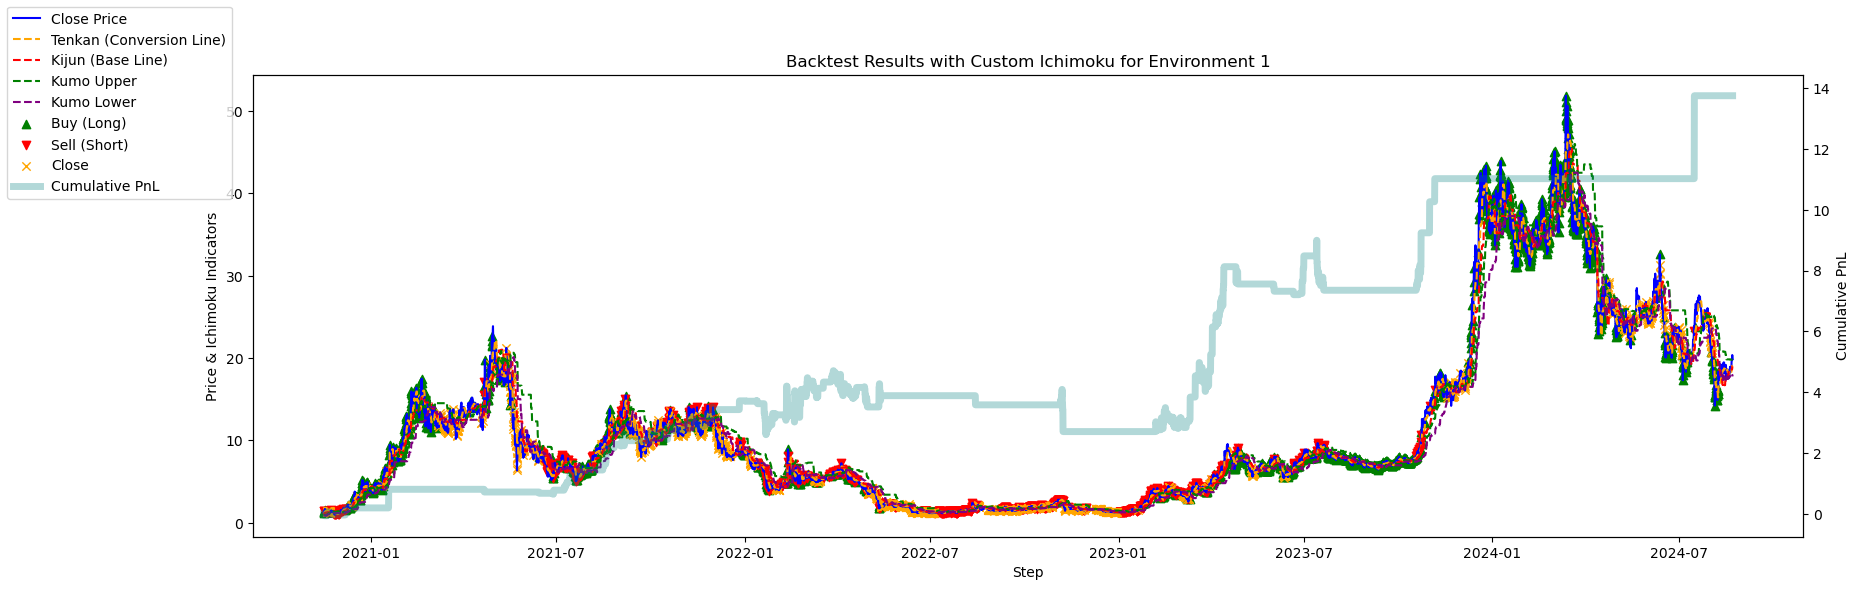

Results for Environment 1:
                     Price  Action  Position        PnL
timestamp                                              
2020-11-15 16:00:00      0       1         1   0.000000
2020-11-15 20:00:00      0       1         1   0.000000
2020-11-16 00:00:00      0       1         1   0.000000
2020-11-16 04:00:00      0       2         0  -0.036309
2020-11-16 08:00:00      0       1         1  -0.036309
...                    ...     ...       ...        ...
2024-08-22 00:00:00      0       0         1  13.751068
2024-08-22 04:00:00      0       0         1  13.751068
2024-08-22 08:00:00      0       0         1  13.751068
2024-08-22 12:00:00      0       0         1  13.751068
2024-08-22 16:00:00      0       0         1  13.751068

[8257 rows x 4 columns]


In [49]:
# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'INJ', 'USDT', '4h', 'binance'
df = load_candles(exchange,asset, quote, timeframe)#['2021':'2024']#.iloc[-35000:-5000]
params = {'conversion_periods':20, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
df_ichimoku = ichimoku_cloud_indicator(df, **params).assign(close=df.close).dropna()
ldf_ichimoku = df_ichimoku.apply(np.log)
logprice = ldf_ichimoku.close.copy()

# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# data = load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2).dropna()

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '8h', 'binance', params)
# lookback_window_size=10
# env = TradingEnv(data, lookback_window_size=lookback_window_size)
lookback_window_size = 4

env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku, logprice, lookback_window_size=10)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)
# env = TradingEnv(ldf_ichimoku,ldf_ichimoku.close, lookback_window_size=lookback_window_size)
# env = make_vec_env( lambda: TradingEnv(data, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

        # Example usage with vectorized results
results_list = backtest_vec(env, lookback_window_size, model=model)
# plot_results_vec(results_list)
plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku)
# env.reset().shape
# Backtest the environment with random actions
# results = backtest(env, lookback_window_size, model=model)
# plot_results(results)

In [15]:
results.Action.value_counts()
results.Position.value_counts()
# results.sum()

NameError: name 'results' is not defined

In [ ]:
# asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
data = load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2).dropna()
# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('ADA', 'USDT', '8h', 'binance', params)
# Initialize the environment
lookback_window_size=3
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:


# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# df = get_data('SOL', 'USDT', '4h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '4h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(df, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:
import matplotlib.pyplot as plt

# Plot the price, cumulative log-return PnL, and buy/sell signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the closing price on the primary y-axis
ax1.plot(env.df.index, env.df['close'], label='Close Price', color='blue', lw=2)

# Plot entry (buy) and exit (sell) signals as vertical lines
for idx, row in tracking_df.iterrows():
    if row['action'] == 2:  # Buy signal
        ax1.axvline(x=idx, color='green', linestyle='--', lw=1, label='Buy')
    elif row['action'] == 0:  # Sell signal
        ax1.axvline(x=idx, color='red', linestyle='--', lw=1, label='Sell')

# Create a secondary y-axis for cumulative log-return PnL
ax2 = ax1.twinx()
ax2.plot(tracking_df.index, tracking_df['cumulative_pnl'], label='Cumulative PnL (Log Returns)', color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Cumulative PnL (Log Returns)')

# Set labels and title
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.set_title('Agent Trading Performance: Price, Entry/Exit, and Cumulative PnL (Log Returns)')

plt.show()
